In [ ]:
import mina
import scanpy as sc
import numpy as np
import decoupler as dc
import math
import mofaflex as mf
import mudata as md
import pandas as pd
import matplotlib.pyplot as plt

/opt/homebrew/Caskroom/miniforge/base/envs/scverse/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [2]:
adata = sc.read_h5ad("../data/HCA/epithelial.h5ad")
sample_lab = "sample_id"
ct_group_lab = "hgca_celltype_level2"

In [3]:
# Filter out cell labels that are nan
adata = adata[adata.obs[ct_group_lab]!="nan", :].copy()
# Filter all dataset_ids with less than 10 unique sample ids
patient_count = adata.obs[["dataset_id",sample_lab]].drop_duplicates()
patient_count = patient_count["dataset_id"].value_counts()
sel_studies = patient_count[patient_count > 10].index.tolist()
adata = adata[adata.obs["dataset_id"].isin(sel_studies), :].copy()

In [7]:
# We extract the metadata based on our column that is the reference
# Filter adata to only include ileum
# Process adata_raw
metadata = mina.up.extract_metadata_from_obs(obs=adata.obs, groupby=sample_lab, sort=False)
pdata = dc.pp.pseudobulk(adata, sample_col=sample_lab, groups_col=ct_group_lab)
# Manipulations on pdata
pdata.obs = pdata.obs.set_index(sample_lab, drop=False)
pdata.obs.index.name = None

# Make list of adatas per pseudobulk cell type
anndata_dict = mina.up.split_anndata_by_celltype(pdata=pdata, grouping=ct_group_lab)

# Adding gene expression total counts - TODO add to upstream as a function
for _cell_type, adata_raw in anndata_dict.items():
    # Sum across observations (rows) for each gene (column)
    if hasattr(adata_raw.X, "toarray"):
        # Sparse matrix case
        total_counts = adata_raw.X.sum(axis=0).A1  # returns 1D array
    else:
        total_counts = adata_raw.X.sum(axis=0)  # numpy array

    # Add to .var
    adata_raw.var["total_counts"] = total_counts

/opt/homebrew/Caskroom/miniforge/base/envs/scverse/lib/python3.12/site-packages/anndata/_core/anndata.py:795: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    ['4918STDY7274839', '4918STDY7333456', '4918STDY7389431', '4918STDY7447825', '4918STDY7702680']

    Inferred to be: categorical



/opt/homebrew/Caskroom/miniforge/base/envs/scverse/lib/python3.12/site-packages/mina/pl/pl.py:53: RuntimeWarning: divide by zero encountered in log10


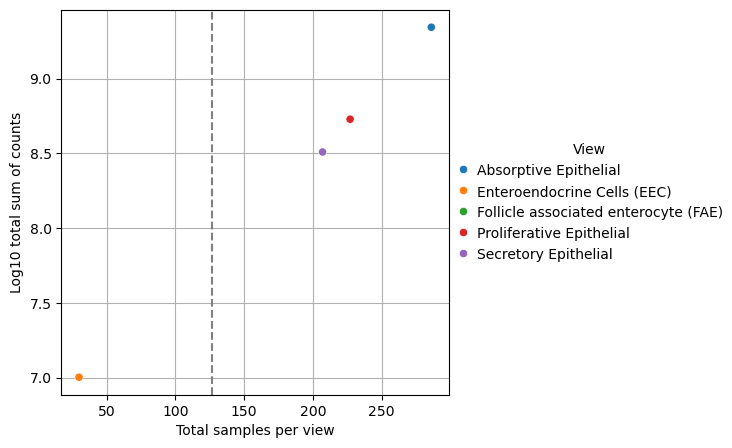

In [9]:
# Making filters
sample_prop = 0.4
mina.up.filt.filter_anndata_by_ncells(anndata_dict, min_cells=20)
# From all the possible samples, let's ask for at least sample_prop%
n_samples = len(metadata.index)
min_samples = math.trunc(n_samples * sample_prop)
mina.pl.plot_view_samples(anndata_dict, min_samples=min_samples)

In [10]:
# From all the possible samples, let's ask for at least 40%
mina.up.filt.filter_views_by_samples(anndata_dict, min_rows=min_samples)
mina.up.filt.filter_genes_byexpr(anndata_dict, min_count=20, min_prop=sample_prop)
mina.up.filt.filter_views_by_genes(anndata_dict, min_genes_per_view=100)
mina.up.filt.filter_samples_by_coverage(anndata_dict, threshold=0, min_prop=0.90)
mina.up.filt.filter_views_by_samples(anndata_dict, min_rows=min_samples)
mina.up.utils.save_raw_counts(anndata_dict, layer_name="raw_counts")
mina.up.norm_log(anndata_dict, target_sum=1e6, exclude_highly_expressed=False, max_value=None, center=True)
mina.up.filter_hvgs(anndata_dict, groupby = "dataset_id", ngroups_cut = 3)
mina.up.filter_smpls_by_nview(anndata_dict, min_views = 2)

Raw counts saved in the 'raw_counts' layer for each AnnData object.
Normalization, log-transformation, and scaling complete for all AnnData objects with target_sum = 1000000.0.


/opt/homebrew/Caskroom/miniforge/base/envs/scverse/lib/python3.12/site-packages/scanpy/preprocessing/_highly_variable_genes.py:383: RuntimeWarning: invalid value encountered in log
/opt/homebrew/Caskroom/miniforge/base/envs/scverse/lib/python3.12/site-packages/scanpy/preprocessing/_highly_variable_genes.py:383: RuntimeWarning: invalid value encountered in log
/opt/homebrew/Caskroom/miniforge/base/envs/scverse/lib/python3.12/site-packages/scanpy/preprocessing/_highly_variable_genes.py:383: RuntimeWarning: invalid value encountered in log
/opt/homebrew/Caskroom/miniforge/base/envs/scverse/lib/python3.12/site-packages/scanpy/preprocessing/_highly_variable_genes.py:383: RuntimeWarning: invalid value encountered in log
/opt/homebrew/Caskroom/miniforge/base/envs/scverse/lib/python3.12/site-packages/scanpy/preprocessing/_highly_variable_genes.py:383: RuntimeWarning: invalid value encountered in log
/opt/homebrew/Caskroom/miniforge/base/envs/scverse/lib/python3.12/site-packages/scanpy/preproce

/opt/homebrew/Caskroom/miniforge/base/envs/scverse/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/opt/homebrew/Caskroom/miniforge/base/envs/scverse/lib/python3.12/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
WARNING	Device cuda is not available. Using default device: cpu


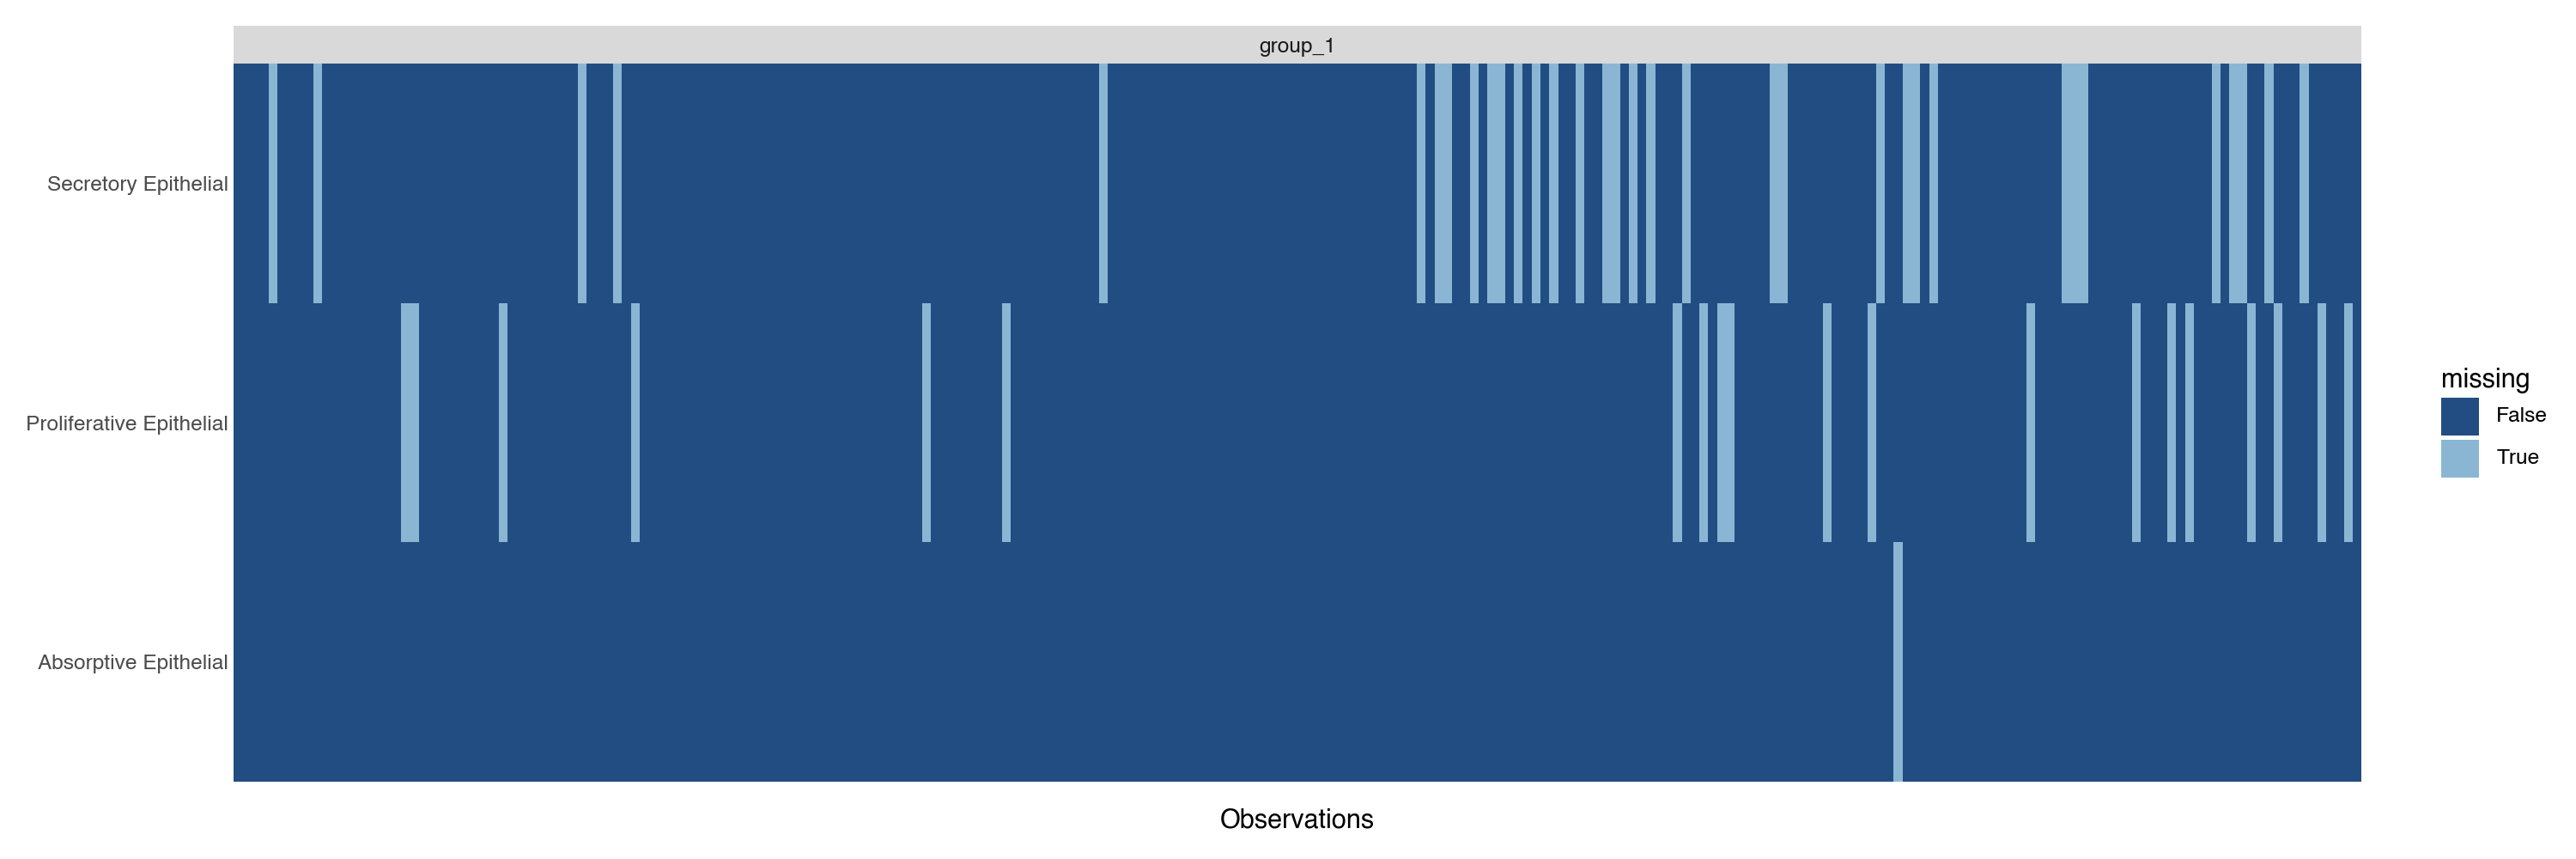

/opt/homebrew/Caskroom/miniforge/base/envs/scverse/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/opt/homebrew/Caskroom/miniforge/base/envs/scverse/lib/python3.12/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/opt/homebrew/Caskroom/miniforge/base/envs/scverse/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalit

In [12]:
# This is necessary before any model fit!
mina.up.utils.append_view_to_var(anndata_dict)
mdata = md.MuData(anndata_dict)
model = mf.MOFAFLEX(
    mdata,
    mf.ModelOptions(n_factors=20, weight_prior="SnS", likelihoods="Normal"),
    mf.TrainingOptions(seed=42, save_path=False, lr=0.01, early_stopper_patience=500)
)

In [13]:
amodel = mina.down.model_to_anndata(
    anndata_dict=anndata_dict,
    metadata=metadata,
    model=model,
)

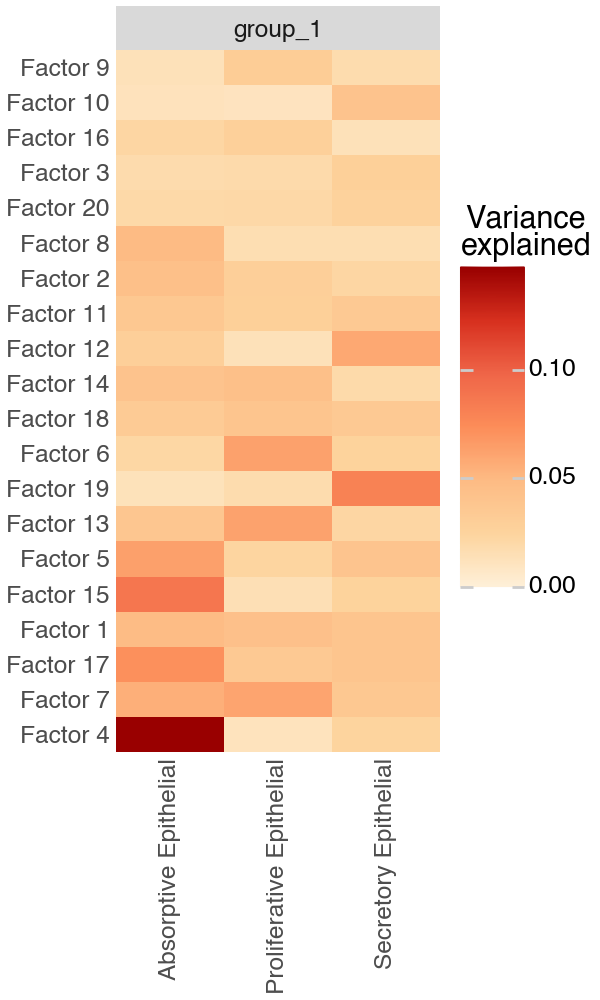

In [14]:
mf.pl.variance_explained(model)

In [29]:
bio_vars = ["sampled_site_condition", "radial_tissue_term", "sample_preservation_method", "sex_ontology_term", "age_range"]
tech_vars =["assay", "sample_collection_method", "sequenced_fragment", "gene_annotation_version"]
tech_vars =["assay", "sample_collection_method", "gene_annotation_version"]

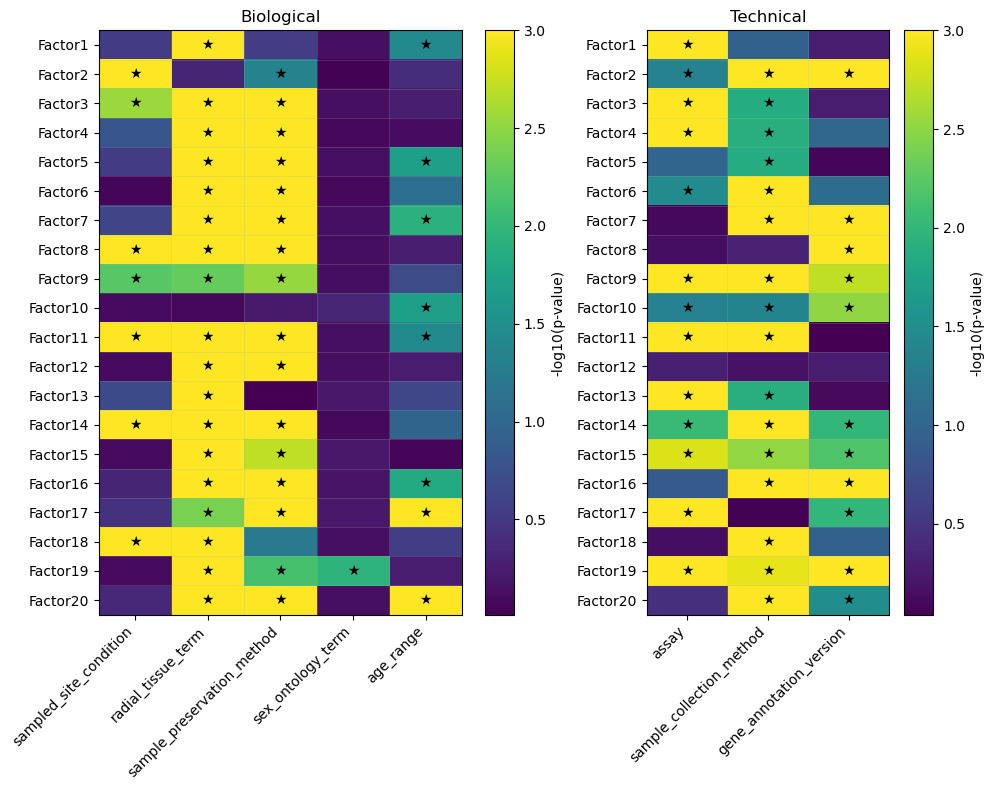

In [40]:
# Get the p-value matrix for the associations of interest (adjusted)
all_assocs_tech = mina.down.get_pval_matrix(amodel, tech_vars)
all_assocs_tech[all_assocs_tech < 0.001] = 0.001

# Get the p-value matrix for the associations of interest (adjusted)
all_assocs_bio = mina.down.get_pval_matrix(amodel, bio_vars)
all_assocs_bio[all_assocs_bio < 0.001] = 0.001

# Plot joined data
fig, axes = plt.subplots(1, 2, figsize=(10, 8),
                         gridspec_kw={"width_ratios": [1.5, 1]})

mina.pl.pl.plot_pval_tiles(all_assocs_bio, ax=axes[0], title="Biological", star_threshold=0.05)
mina.pl.pl.plot_pval_tiles(all_assocs_tech, ax=axes[1], title="Technical", star_threshold=0.05)

plt.show()

In [44]:
# Making this now an explained variance plot
all_results = []

for q_var in bio_vars + tech_vars:

    fraction_stats = mina.down.get_associations(amodel, 
                           test_variable = q_var,
                           test_type="categorical",
                           random_effect = None)

    res = mina.down.calc_total_variance(amodel, fraction_stats, pval_thrs=0.05) # Using the statistics from above

    tmp = (
        pd.DataFrame(res)
        .T
        .rename_axis("cell_type")
        .reset_index()
        .rename(columns={"group_1": "R2"})
    )
    tmp["covariate"] = q_var
    if q_var in bio_vars:
        tmp["covariate_type"] = "biological"
    else:
        tmp["covariate_type"] = "technical"

    all_results.append(tmp)

combined = pd.concat(all_results, ignore_index=True)

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.gridspec import GridSpec


def plot_r2_heatmap(
    df,
    cell_col="cell_type",
    covariate_col="covariate",
    value_col="R2",
    covariate_type_col="covariate_type",
    covariate_type_order=("biological", "technical"),
    covariate_type_colors=None,
    cmap="magma",
    figsize=(12, 6),
    text_fmt="{:.3f}",
    xtick_fontsize=10,
    ytick_fontsize=10,
    cell_fontsize=8,
    group_fontsize=10,
    axis_label_fontsize=11,
    colorbar_fontsize=10,
):
    if covariate_type_colors is None:
        covariate_type_colors = {
            "biological": "#4CA37A",
            "technical": "#6AA5D4",
        }

    # Covariate annotation
    cov_type = (
        df[[covariate_col, covariate_type_col]]
        .drop_duplicates()
        .set_index(covariate_col)[covariate_type_col]
    )

    # Sort covariates by category, then name
    cov_order = (
        pd.DataFrame({
            covariate_col: cov_type.index,
            covariate_type_col: cov_type.values,
        })
        .assign(
            type_rank=lambda x: pd.Categorical(
                x[covariate_type_col],
                categories=list(covariate_type_order),
                ordered=True,
            )
        )
        .sort_values(["type_rank", covariate_col])[covariate_col]
        .tolist()
    )

    # Full R2 matrix: rows = cell types, columns = covariates
    mat = (
        df.pivot_table(
            index=cell_col,
            columns=covariate_col,
            values=value_col,
            aggfunc="max",
            fill_value=0,
        )
        .reindex(columns=cov_order, fill_value=0)
    )

    # Sort cell types by their strongest associated covariate
    row_order = (
        pd.DataFrame({
            cell_col: mat.index,
            "best_covariate": mat.idxmax(axis=1).values,
            "max_r2": mat.max(axis=1).values,
        })
        .assign(
            cov_rank=lambda x: pd.Categorical(
                x["best_covariate"],
                categories=cov_order,
                ordered=True,
            )
        )
        .sort_values(["cov_rank", "max_r2"], ascending=[True, False])[cell_col]
        .tolist()
    )

    mat = mat.loc[row_order]

    fig = plt.figure(figsize=figsize)

    gs = GridSpec(
        2,
        2,
        width_ratios=[40, 2.5],
        height_ratios=[1.2, 8],
        wspace=0.15,
        hspace=0.08,
        figure=fig,
    )

    ax_top = fig.add_subplot(gs[0, 0])
    ax = fig.add_subplot(gs[1, 0])
    cax = fig.add_subplot(gs[1, 1])

    # Main heatmap: raw R2, fixed 0–1 scale
    im = ax.imshow(
        mat.values,
        aspect="auto",
        cmap=cmap,
        vmin=0,
        vmax=1,
        interpolation="nearest",
    )

    ax.set_xticks(np.arange(mat.shape[1]))
    ax.set_xticklabels(
        mat.columns,
        rotation=45,
        ha="right",
        fontsize=xtick_fontsize,
    )

    ax.set_yticks(np.arange(mat.shape[0]))
    ax.set_yticklabels(
        mat.index,
        fontsize=ytick_fontsize,
    )

    ax.set_xlabel("Covariate", fontsize=axis_label_fontsize)
    ax.set_ylabel("Cell type", fontsize=axis_label_fontsize)

    ax.tick_params(axis="x", labelsize=xtick_fontsize)
    ax.tick_params(axis="y", labelsize=ytick_fontsize)

    # Cell labels
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat.iat[i, j]
            text_color = "white" if val < 0.55 else "black"
            ax.text(
                j,
                i,
                text_fmt.format(val),
                ha="center",
                va="center",
                fontsize=cell_fontsize,
                color=text_color,
            )

    for spine in ax.spines.values():
        spine.set_visible(False)

    # R2 colorbar
    cb = fig.colorbar(im, cax=cax)
    cb.set_label(value_col, fontsize=colorbar_fontsize)
    cb.ax.tick_params(labelsize=colorbar_fontsize)

    # Top covariate-type band
    cov_types = [cov_type[c] for c in mat.columns]

    ax_top.set_xlim(-0.5, mat.shape[1] - 0.5)
    ax_top.set_ylim(0, 1)

    start = 0
    current_type = cov_types[0]

    for i in range(1, len(cov_types) + 1):
        if i == len(cov_types) or cov_types[i] != current_type:
            end = i - 1
            width = end - start + 1

            ax_top.add_patch(
                Rectangle(
                    (start - 0.5, 0),
                    width,
                    1,
                    facecolor=covariate_type_colors[current_type],
                    edgecolor="white",
                    linewidth=1.2,
                )
            )

            ax_top.text(
                start + (width - 1) / 2,
                0.5,
                current_type.capitalize(),
                ha="center",
                va="center",
                fontsize=group_fontsize,
                fontweight="bold",
            )

            if i < len(cov_types):
                start = i
                current_type = cov_types[i]

    ax_top.axis("off")

    return fig, ax, mat

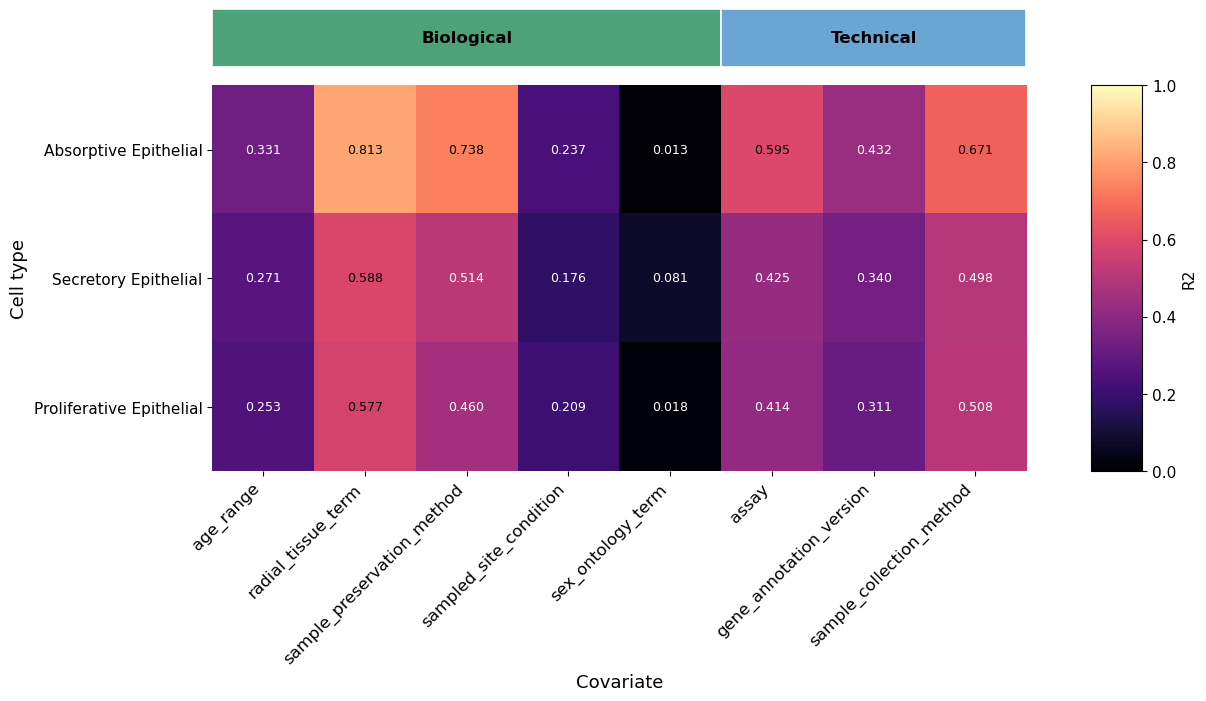

In [74]:
fig, ax, mat = plot_r2_heatmap(
    combined,
    xtick_fontsize=12,
    ytick_fontsize=11,
    cell_fontsize=9,
    group_fontsize=12,
    axis_label_fontsize=13,
    colorbar_fontsize=11,
)
plt.show()